
PARKINSON'S DISEASE DETECTION - OPTIMIZED
## Practical Colab notebook for better test accuracy on spiral drawings

**Dataset:** https://www.kaggle.com/datasets/kmader/parkinsons-drawings  
**Models:** VGG19, InceptionV3, ResNet50V2, DenseNet169  
**Goal:** Improve practical test accuracy while keeping a notebook structure similar to the original demo.  
**Key changes:** proper preprocessing, lighter augmentation, validation split from train only, two-stage fine-tuning, checkpoint by val AUC, threshold tuning on validation before final test.

---
## STEP 1: SETUP & MOUNT GOOGLE DRIVE

In [1]:
# Import libraries
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.applications import DenseNet169, InceptionV3, ResNet50V2, VGG19
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnetv2_preprocess
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('Libraries imported!')
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

Libraries imported!
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('\nGoogle Drive mounted!')
except Exception as e:
    print('Google Drive mount skipped:', e)

Mounted at /content/drive

Google Drive mounted!


In [3]:
class HistoryContainer:
    def __init__(self, history):
        self.history = history


def merge_histories(*histories):
    merged = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(list(values))
    return HistoryContainer(merged)


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['auc'], label='Train AUC', linewidth=2)
    axes[1].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1].set_title(f'{model_name} - AUC', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    axes[2].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[2].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[2].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Loss', fontsize=12)
    axes[2].legend(fontsize=11)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Plot saved: {model_name}_training_history.png\n')


def safe_roc_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return float('nan')


def find_best_threshold(model, val_generator):
    val_generator.reset()
    y_score = model.predict(val_generator, verbose=0).ravel()
    y_true = val_generator.classes

    # Optimize for validation accuracy because the final notebook ranking uses test accuracy.
    threshold_grid = np.linspace(0.25, 0.75, 51)
    best_threshold = 0.5
    best_acc = -1.0
    best_balanced_acc = -1.0
    best_f1 = -1.0

    for threshold in threshold_grid:
        y_pred = (y_score >= threshold).astype(int)
        acc = accuracy_score(y_true, y_pred)
        balanced_acc = balanced_accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if (acc > best_acc) or (acc == best_acc and balanced_acc > best_balanced_acc) or (acc == best_acc and balanced_acc == best_balanced_acc and f1 > best_f1) or (acc == best_acc and balanced_acc == best_balanced_acc and f1 == best_f1 and abs(threshold - 0.5) < abs(best_threshold - 0.5)):
            best_threshold = float(threshold)
            best_acc = float(acc)
            best_balanced_acc = float(balanced_acc)
            best_f1 = float(f1)

    print(f'Best validation threshold: {best_threshold:.2f}')
    print(f'Validation accuracy at best threshold: {best_acc:.4f}')
    print(f'Validation balanced accuracy at best threshold: {best_balanced_acc:.4f}')
    print(f'Validation F1 at best threshold: {best_f1:.4f}')

    return best_threshold


def evaluate_model(model, generator, model_name, threshold=0.5):
    generator.reset()

    y_score = model.predict(generator, verbose=0).ravel()
    y_pred = (y_score >= threshold).astype(int)
    y_true = generator.classes

    eval_values = model.evaluate(generator, verbose=0)
    test_loss = eval_values[0]
    test_auc = safe_roc_auc(y_true, y_score)
    test_acc = accuracy_score(y_true, y_pred)

    target_names = [label for label, _ in sorted(generator.class_indices.items(), key=lambda item: item[1])]

    print(f'\nCLASSIFICATION REPORT - {model_name}')
    print('=' * 60)
    print(f'Threshold used: {threshold:.2f}')
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Confusion Matrix saved: {model_name}_confusion_matrix.png')

    return {
        'test_acc': float(test_acc),
        'test_loss': float(test_loss),
        'test_auc': float(test_auc),
        'threshold': float(threshold),
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_score': y_score,
    }


print('Plotting and evaluation functions defined!')

Plotting and evaluation functions defined!


---
## STEP 2: PREPARE DATA

In [4]:
# Configuration
DATASET_PATH = '/content/drive/MyDrive/Parkinsons/drawings/spiral'
TRAIN_PATH = os.path.join(DATASET_PATH, 'training')
TEST_PATH = os.path.join(DATASET_PATH, 'testing')
SAVE_PATH = '/content/drive/MyDrive/Parkinson_Models_Optimized'
CHECKPOINT_PATH = '/content/Parkinson_Checkpoints_Optimized'
RANDOM_SEED = 42
VAL_SIZE_FROM_TRAIN = 0.2
HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 15

print('Configuration:')
print('  Dataset path:', DATASET_PATH)
print('  Train path:', TRAIN_PATH)
print('  Test path:', TEST_PATH)
print('  Save path:', SAVE_PATH)
print('  Checkpoint path:', CHECKPOINT_PATH)
print('  Validation size from train:', VAL_SIZE_FROM_TRAIN)
print('  Head epochs:', HEAD_EPOCHS)
print('  Fine-tune epochs:', FINE_TUNE_EPOCHS)

Configuration:
  Dataset path: /content/drive/MyDrive/Parkinsons/drawings/spiral
  Train path: /content/drive/MyDrive/Parkinsons/drawings/spiral/training
  Test path: /content/drive/MyDrive/Parkinsons/drawings/spiral/testing
  Save path: /content/drive/MyDrive/Parkinson_Models_Optimized
  Checkpoint path: /content/Parkinson_Checkpoints_Optimized
  Validation size from train: 0.2
  Head epochs: 10
  Fine-tune epochs: 15


In [5]:
# Reproducibility and directories
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

print('Seed fixed and directories ready!')

Seed fixed and directories ready!


In [6]:
def collect_split_df(split_dir):
    rows = []
    for label in ['healthy', 'parkinson']:
        label_dir = os.path.join(split_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for filename in sorted(os.listdir(label_dir)):
            file_path = os.path.join(label_dir, filename)
            if os.path.isfile(file_path):
                rows.append({'filepath': file_path, 'label': label})
    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f'No images found in: {split_dir}')
    return df


train_full_df = collect_split_df(TRAIN_PATH)
test_df = collect_split_df(TEST_PATH)

print('Training pool collected:', len(train_full_df))
print(train_full_df['label'].value_counts())
print('\nExternal test set collected:', len(test_df))
print(test_df['label'].value_counts())

Training pool collected: 72
label
healthy      36
parkinson    36
Name: count, dtype: int64

External test set collected: 30
label
healthy      15
parkinson    15
Name: count, dtype: int64


In [7]:
# Keep the original 30-image test set untouched and split validation only from train
train_df, val_df = train_test_split(
    train_full_df,
    test_size=VAL_SIZE_FROM_TRAIN,
    stratify=train_full_df['label'],
    random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Data split complete!')
print('  Train samples:', len(train_df))
print('  Validation samples:', len(val_df))
print('  Test samples:', len(test_df))

print('\nTrain class balance:')
print(train_df['label'].value_counts())
print('\nValidation class balance:')
print(val_df['label'].value_counts())
print('\nTest class balance:')
print(test_df['label'].value_counts())

Data split complete!
  Train samples: 57
  Validation samples: 15
  Test samples: 30

Train class balance:
label
parkinson    29
healthy      28
Name: count, dtype: int64

Validation class balance:
label
healthy      8
parkinson    7
Name: count, dtype: int64

Test class balance:
label
healthy      15
parkinson    15
Name: count, dtype: int64


In [8]:
# Save splits for reproducibility
split_dir = os.path.join(SAVE_PATH, 'splits')
os.makedirs(split_dir, exist_ok=True)

train_df.to_csv(os.path.join(split_dir, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(split_dir, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(split_dir, 'test_split.csv'), index=False)

print('Split CSV files saved to:', split_dir)

Split CSV files saved to: /content/drive/MyDrive/Parkinson_Models_Optimized/splits


---
## STEP 3: BUILD MODELS

In [9]:
MODEL_CONFIGS = {
    'VGG19': {
        'builder': VGG19,
        'preprocess': vgg19_preprocess,
        'img_size': 224,
        'batch_size': 8,
        'head_lr': 1e-4,
        'ft_lr': 5e-6,
        'dense_units': 128,
        'dropout': 0.30,
        'fine_tune_layers': 8,
    },
    'InceptionV3': {
        'builder': InceptionV3,
        'preprocess': inception_preprocess,
        'img_size': 224,
        'batch_size': 8,
        'head_lr': 1e-4,
        'ft_lr': 5e-6,
        'dense_units': 128,
        'dropout': 0.50,
        'fine_tune_layers': 0,
        'head_epochs': 20,
        'fine_tune_epochs': 8,
        'monitor': 'val_loss',
        'monitor_mode': 'min',
    },
    'ResNet50V2': {
        'builder': ResNet50V2,
        'preprocess': resnetv2_preprocess,
        'img_size': 224,
        'batch_size': 16,
        'head_lr': 1e-4,
        'ft_lr': 1e-5,
        'dense_units': 128,
        'dropout': 0.30,
        'fine_tune_layers': 40,
    },
    'DenseNet169': {
        'builder': DenseNet169,
        'preprocess': densenet_preprocess,
        'img_size': 224,
        'batch_size': 8,
        'head_lr': 1e-4,
        'ft_lr': 5e-6,
        'dense_units': 128,
        'dropout': 0.25,
        'fine_tune_layers': 60,
    },
}

print('Model configs defined!')
for name, cfg in MODEL_CONFIGS.items():
    print(f"  {name}: img={cfg['img_size']}, batch={cfg['batch_size']}, head_lr={cfg['head_lr']}, ft_lr={cfg['ft_lr']}, ft_layers={cfg['fine_tune_layers']}")

Model configs defined!
  VGG19: img=224, batch=8, head_lr=0.0001, ft_lr=5e-06, ft_layers=8
  InceptionV3: img=224, batch=16, head_lr=0.0001, ft_lr=1e-05, ft_layers=40
  ResNet50V2: img=224, batch=16, head_lr=0.0001, ft_lr=1e-05, ft_layers=40
  DenseNet169: img=224, batch=8, head_lr=0.0001, ft_lr=5e-06, ft_layers=60


In [10]:
def create_generators(config):
    # Lighter augmentation works better on this small spiral dataset.
    train_datagen = ImageDataGenerator(
        preprocessing_function=config['preprocess'],
        rotation_range=12,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.05,
        fill_mode='nearest'
    )

    eval_datagen = ImageDataGenerator(preprocessing_function=config['preprocess'])

    train_generator = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filepath',
        y_col='label',
        target_size=(config['img_size'], config['img_size']),
        batch_size=config['batch_size'],
        class_mode='binary',
        shuffle=True,
        seed=RANDOM_SEED
    )

    val_generator = eval_datagen.flow_from_dataframe(
        val_df,
        x_col='filepath',
        y_col='label',
        target_size=(config['img_size'], config['img_size']),
        batch_size=config['batch_size'],
        class_mode='binary',
        shuffle=False
    )

    test_generator = eval_datagen.flow_from_dataframe(
        test_df,
        x_col='filepath',
        y_col='label',
        target_size=(config['img_size'], config['img_size']),
        batch_size=config['batch_size'],
        class_mode='binary',
        shuffle=False
    )

    return train_generator, val_generator, test_generator


def compile_model(model, learning_rate):
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )


def set_trainable_layers(base_model, fine_tune_layers):
    for layer in base_model.layers:
        layer.trainable = False

    if fine_tune_layers <= 0:
        return

    for layer in base_model.layers[-fine_tune_layers:]:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True


def create_model(config, model_name):
    base_model = config['builder'](
        weights='imagenet',
        include_top=False,
        input_shape=(config['img_size'], config['img_size'], 3)
    )

    set_trainable_layers(base_model, 0)

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(config['dense_units'], activation='relu')(x)
    x = Dropout(config['dropout'])(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    compile_model(model, config['head_lr'])

    print(f'\n{model_name} created!')
    print(f"  Total params: {model.count_params():,}")
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"  Trainable params: {trainable_params:,}")

    return model, base_model


def get_callbacks(model_name, phase_name, config):
    checkpoint_file = os.path.join(CHECKPOINT_PATH, f'{model_name}_{phase_name}.weights.h5')
    monitor = config.get('monitor', 'val_auc')
    monitor_mode = config.get('monitor_mode', 'max')

    lr_reducer = ReduceLROnPlateau(
        monitor=monitor,
        factor=np.sqrt(0.1),
        patience=4,
        min_lr=1e-7,
        mode=monitor_mode,
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor=monitor,
        patience=8,
        restore_best_weights=True,
        mode=monitor_mode,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_file,
        monitor=monitor,
        save_best_only=True,
        save_weights_only=True,
        mode=monitor_mode,
        verbose=1
    )

    return [lr_reducer, early_stop, checkpoint], checkpoint_file


def train_model(model_name):
    config = MODEL_CONFIGS[model_name]
    head_epochs = config.get('head_epochs', HEAD_EPOCHS)
    fine_tune_epochs = config.get('fine_tune_epochs', FINE_TUNE_EPOCHS)
    train_generator, val_generator, test_generator = create_generators(config)

    print(f'  Train batches: {len(train_generator)}')
    print(f'  Val batches: {len(val_generator)}')
    print(f'  Test batches: {len(test_generator)}')

    model, base_model = create_model(config, model_name)

    # Phase 1: train only the new classification head.
    print('\nPhase 1: train head only')
    callbacks_head, checkpoint_head = get_callbacks(model_name, 'head', config)
    history_head = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=head_epochs,
        callbacks=callbacks_head,
        verbose=1
    )

    if os.path.exists(checkpoint_head):
        model.load_weights(checkpoint_head)
        print(f'Loaded best head checkpoint: {checkpoint_head}')

    # Phase 2: fine-tune the backbone or continue training the head with a lower LR.
    if config['fine_tune_layers'] > 0:
        print('\nPhase 2: fine-tune last layers')
    else:
        print('\nPhase 2: continue head training at lower LR')
    set_trainable_layers(base_model, config['fine_tune_layers'])
    compile_model(model, config['ft_lr'])

    fine_tune_trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f'  Fine-tune trainable params: {fine_tune_trainable:,}')

    callbacks_ft, checkpoint_ft = get_callbacks(model_name, 'finetune', config)
    history_ft = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=fine_tune_epochs,
        callbacks=callbacks_ft,
        verbose=1
    )

    best_checkpoint = checkpoint_ft if os.path.exists(checkpoint_ft) else checkpoint_head
    if os.path.exists(best_checkpoint):
        model.load_weights(best_checkpoint)
        print(f'Loaded best fine-tuned checkpoint: {best_checkpoint}')

    merged_history = merge_histories(history_head, history_ft)
    plot_training_history(merged_history, model_name)

    best_threshold = find_best_threshold(model, val_generator)
    eval_results = evaluate_model(model, test_generator, model_name, threshold=best_threshold)

    return {
        'history': merged_history,
        'test_acc': eval_results['test_acc'],
        'test_loss': eval_results['test_loss'],
        'test_auc': eval_results['test_auc'],
        'threshold': eval_results['threshold'],
        'model': model,
        'eval': eval_results,
        'config': config,
    }


print('Model helper functions defined!')

Model helper functions defined!


---
## STEP 4: TRAIN MODELS

In [11]:
# Dictionary to store results
results = {}

print('Starting training process...\n')
print('=' * 60)

Starting training process...



### 4.1. VGG19


TRAINING MODEL 1/4: VGG19
Found 57 validated image filenames belonging to 2 classes.
Found 15 validated image filenames belonging to 2 classes.
Found 30 validated image filenames belonging to 2 classes.
  Train batches: 8
  Val batches: 2
  Test batches: 4
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

VGG19 created!
  Total params: 20,090,177
  Trainable params: 65,793

Phase 1: train head only
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4655 - auc: 0.5114 - loss: 1.3474
Epoch 1: val_auc improved from None to 0.52679, saving model to /content/Parkinson_Checkpoints_Optimized/VGG19_head.weights.h5

Epoch 1: finished saving model to /content/Parkinson_Checkpoints_Optimized/VGG19_head.weights.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step - accuracy: 0.5263 - auc: 0.5240 - loss: 1.1665 - val_accuracy: 0.6667 - val_auc: 0.5268 - val_loss: 0.8164 - learning_rate: 1.0000e-04
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.4242 - auc: 0.4320 - loss: 1.1432
Epoc

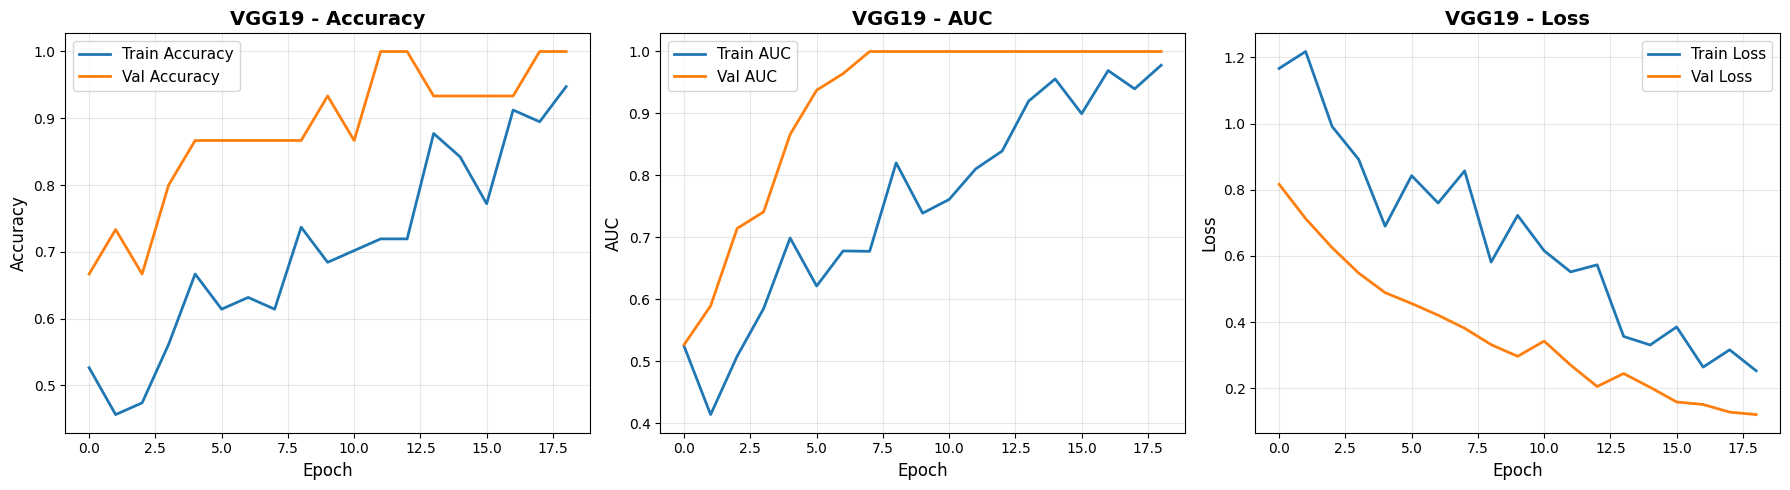

Plot saved: VGG19_training_history.png

Best validation threshold: 0.36
Validation balanced accuracy at best threshold: 1.0000
Validation F1 at best threshold: 1.0000

CLASSIFICATION REPORT - VGG19
Threshold used: 0.36
              precision    recall  f1-score   support

     healthy     0.7778    0.9333    0.8485        15
   parkinson     0.9167    0.7333    0.8148        15

    accuracy                         0.8333        30
   macro avg     0.8472    0.8333    0.8316        30
weighted avg     0.8472    0.8333    0.8316        30



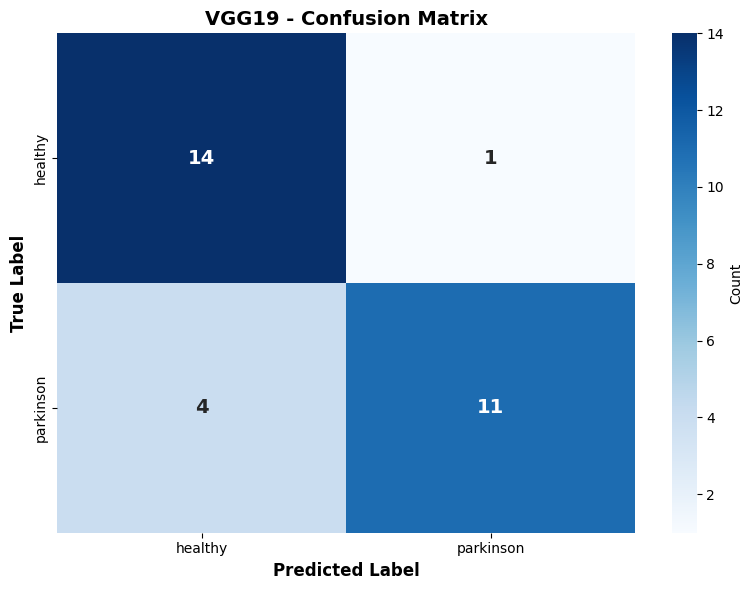

Confusion Matrix saved: VGG19_confusion_matrix.png

VGG19 TRAINING COMPLETE!
  Test Accuracy: 83.33%
  Test AUC: 0.7778
  Threshold: 0.36
  Test Loss: 0.6369


In [12]:
print('\n' + '=' * 60)
print('TRAINING MODEL 1/4: VGG19')
print('=' * 60)

results['VGG19'] = train_model('VGG19')

print(f"\n{'=' * 60}")
print('VGG19 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['VGG19']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['VGG19']['test_auc']:.4f}")
print(f"  Threshold: {results['VGG19']['threshold']:.2f}")
print(f"  Test Loss: {results['VGG19']['test_loss']:.4f}")
print(f"{'=' * 60}")

### 4.2. InceptionV3


TRAINING MODEL 2/4: InceptionV3
Found 57 validated image filenames belonging to 2 classes.
Found 15 validated image filenames belonging to 2 classes.
Found 30 validated image filenames belonging to 2 classes.
  Train batches: 4
  Val batches: 1
  Test batches: 2
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step

InceptionV3 created!
  Total params: 22,065,185
  Trainable params: 262,401

Phase 1: train head only
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5122 - auc: 0.5529 - loss: 0.7403
Epoch 1: val_auc improved from None to 0.93750, saving model to /content/Parkinson_Checkpoints_Optimized/InceptionV3_head.weights.h5

Epoch 1: finished saving model to /content/Parkinson_Checkpoints_Optimized/InceptionV3_head.weights.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.5789 - auc: 0.5702 - loss: 0.7242 - val_accuracy: 0.8000 - val_auc: 0.9375 - val_loss: 0.5199 - learning_rate: 1.0000e-04
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.4835 - auc: 0

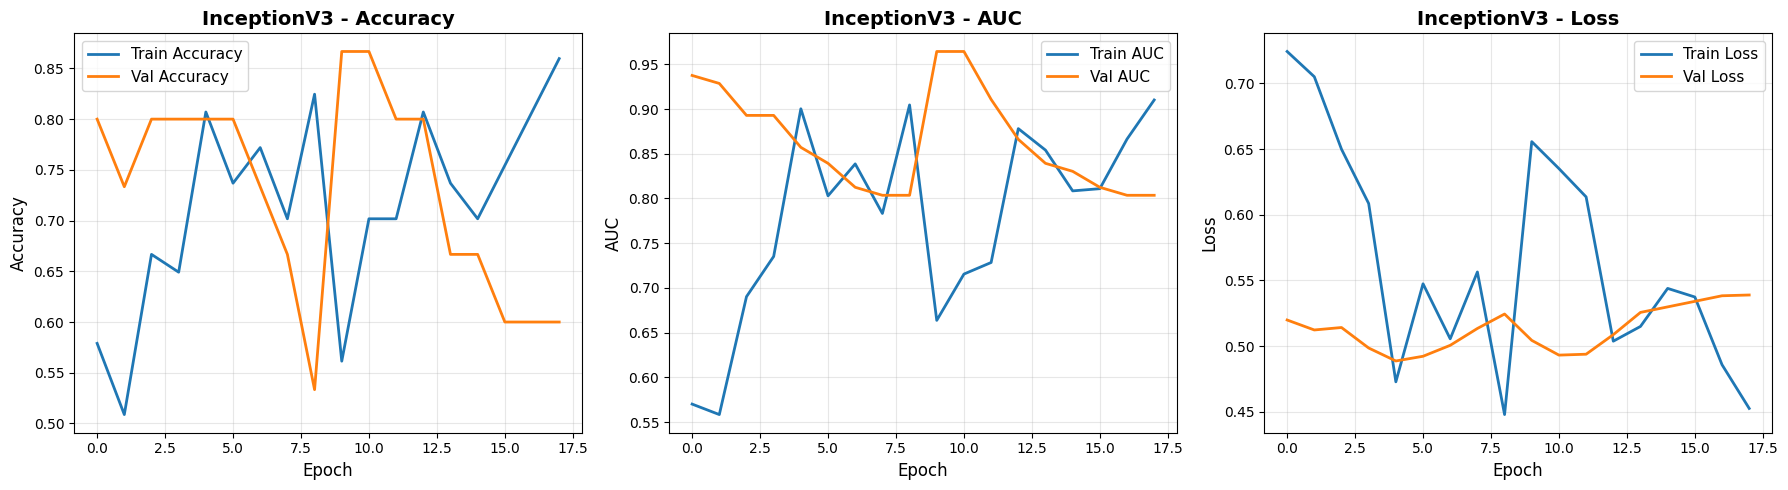

Plot saved: InceptionV3_training_history.png

Best validation threshold: 0.48
Validation balanced accuracy at best threshold: 0.9375
Validation F1 at best threshold: 0.9333



CLASSIFICATION REPORT - InceptionV3
Threshold used: 0.48
              precision    recall  f1-score   support

     healthy     0.8182    0.6000    0.6923        15
   parkinson     0.6842    0.8667    0.7647        15

    accuracy                         0.7333        30
   macro avg     0.7512    0.7333    0.7285        30
weighted avg     0.7512    0.7333    0.7285        30



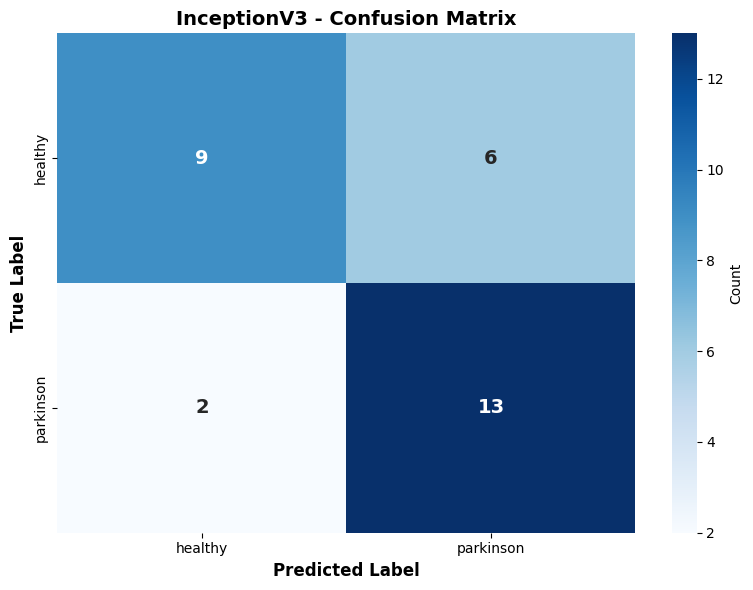

Confusion Matrix saved: InceptionV3_confusion_matrix.png

InceptionV3 TRAINING COMPLETE!
  Test Accuracy: 73.33%
  Test AUC: 0.8978
  Threshold: 0.48
  Test Loss: 0.5364


In [15]:
print('\n' + '=' * 60)
print('TRAINING MODEL 2/4: InceptionV3')
print('=' * 60)

results['InceptionV3'] = train_model('InceptionV3')

print(f"\n{'=' * 60}")
print('InceptionV3 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['InceptionV3']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['InceptionV3']['test_auc']:.4f}")
print(f"  Threshold: {results['InceptionV3']['threshold']:.2f}")
print(f"  Test Loss: {results['InceptionV3']['test_loss']:.4f}")
print(f"{'=' * 60}")

### 4.3. ResNet50V2


TRAINING MODEL 3/4: ResNet50V2
Found 57 validated image filenames belonging to 2 classes.
Found 15 validated image filenames belonging to 2 classes.
Found 30 validated image filenames belonging to 2 classes.
  Train batches: 4
  Val batches: 1
  Test batches: 2
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

ResNet50V2 created!
  Total params: 23,827,201
  Trainable params: 262,401

Phase 1: train head only
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4083 - auc: 0.3706 - loss: 0.8443   
Epoch 1: val_auc improved from None to 0.78571, saving model to /content/Parkinson_Checkpoints_Optimized/ResNet50V2_head.weights.h5

Epoch 1: finished saving model to /content/Parkinson_Checkpoints_Optimized/ResNet50V2_head.weights.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.4561 - auc: 0.4501 - loss: 0.8012 - val_accuracy: 0.6000 - val_auc: 0.7857 - val_loss: 0.6341 - learning_rate: 1.0000e-04
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.4942 - auc: 0.

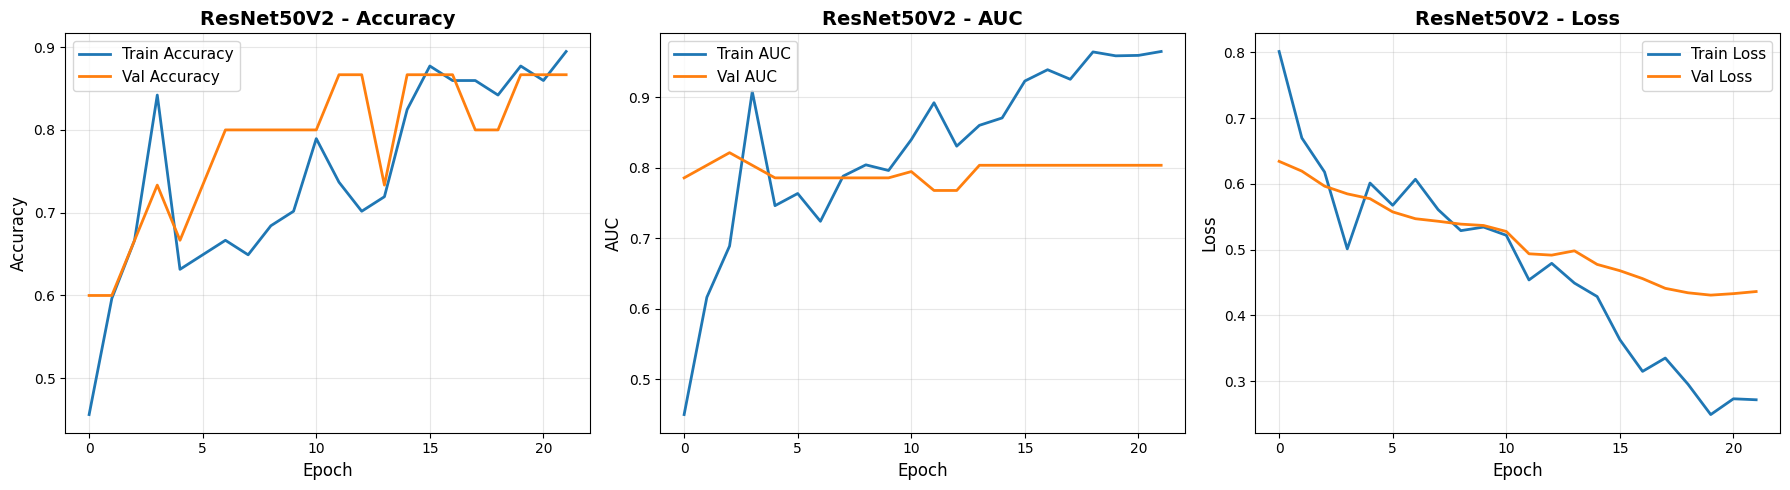

Plot saved: ResNet50V2_training_history.png



Best validation threshold: 0.54
Validation balanced accuracy at best threshold: 0.8571
Validation F1 at best threshold: 0.8333

CLASSIFICATION REPORT - ResNet50V2
Threshold used: 0.54
              precision    recall  f1-score   support

     healthy     0.7143    0.6667    0.6897        15
   parkinson     0.6875    0.7333    0.7097        15

    accuracy                         0.7000        30
   macro avg     0.7009    0.7000    0.6997        30
weighted avg     0.7009    0.7000    0.6997        30



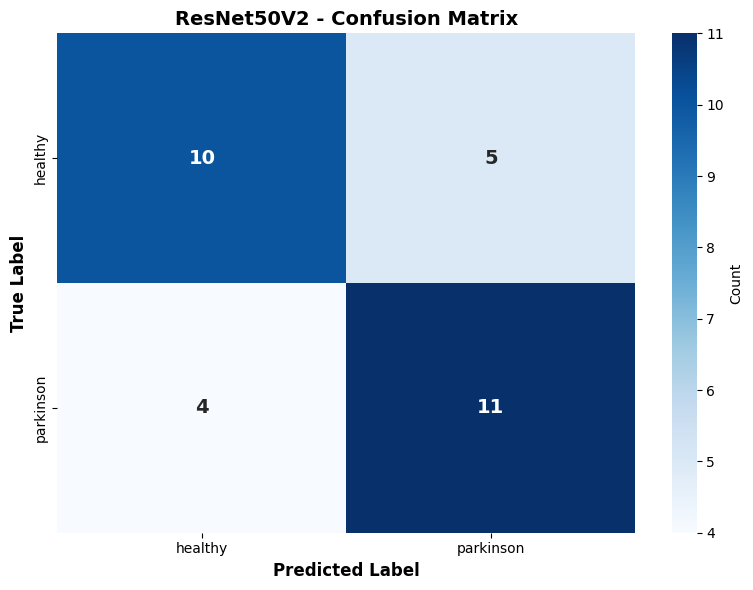

Confusion Matrix saved: ResNet50V2_confusion_matrix.png

ResNet50V2 TRAINING COMPLETE!
  Test Accuracy: 70.00%
  Test AUC: 0.7778
  Threshold: 0.54
  Test Loss: 0.5426


In [16]:
print('\n' + '=' * 60)
print('TRAINING MODEL 3/4: ResNet50V2')
print('=' * 60)

results['ResNet50V2'] = train_model('ResNet50V2')

print(f"\n{'=' * 60}")
print('ResNet50V2 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['ResNet50V2']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['ResNet50V2']['test_auc']:.4f}")
print(f"  Threshold: {results['ResNet50V2']['threshold']:.2f}")
print(f"  Test Loss: {results['ResNet50V2']['test_loss']:.4f}")
print(f"{'=' * 60}")

### 4.4. DenseNet169


TRAINING MODEL 4/4: DenseNet169
Found 57 validated image filenames belonging to 2 classes.
Found 15 validated image filenames belonging to 2 classes.
Found 30 validated image filenames belonging to 2 classes.
  Train batches: 8
  Val batches: 2
  Test batches: 4
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

DenseNet169 created!
  Total params: 12,856,129
  Trainable params: 213,249

Phase 1: train head only
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4284 - auc: 0.4560 - loss: 0.7318
Epoch 1: val_auc improved from None to 0.44643, saving model to /content/Parkinson_Checkpoints_Optimized/DenseNet169_head.weights.h5

Epoch 1: finished saving model to /content/Parkinson_Checkpoints_Optimized/DenseNet169_head.weights.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 101s 9s/step - accuracy: 0.5614 - auc: 0.6139 - loss: 0.6748 - val_accuracy: 0.7333 - val_auc: 0.4464 - val_loss: 0.6865 - learning_rate: 1.0000e-04
Epoch 2/10
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.5928 - auc: 

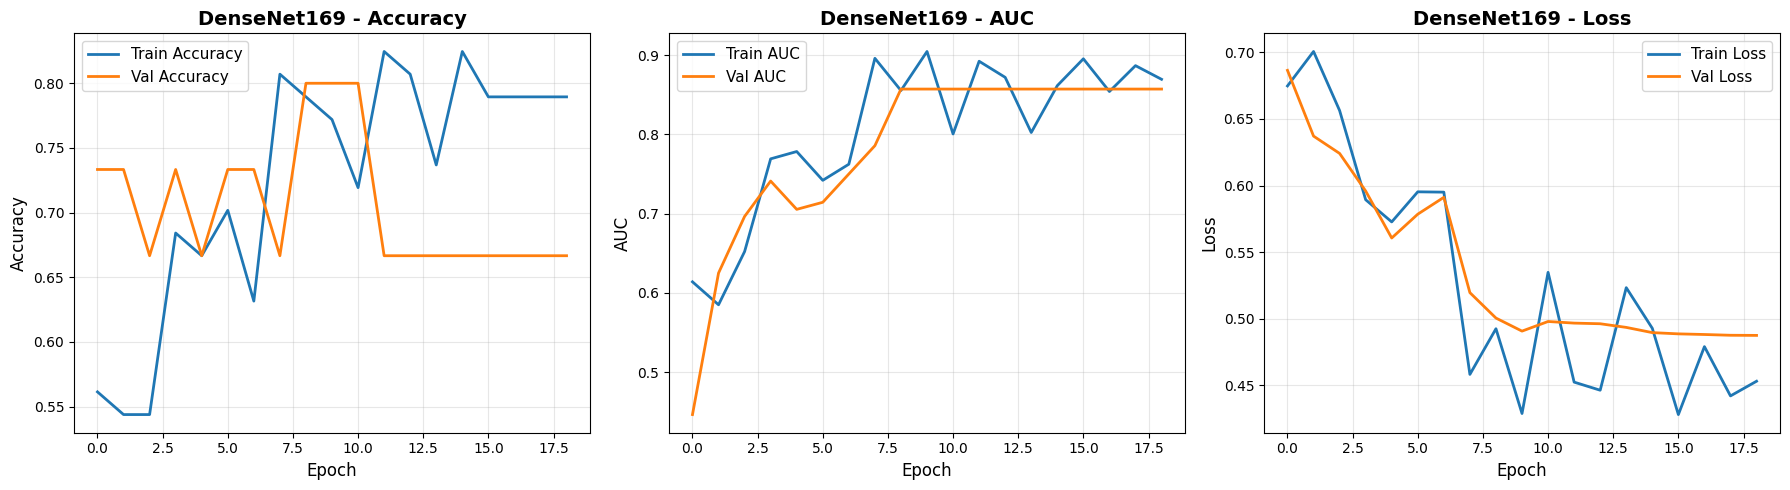

Plot saved: DenseNet169_training_history.png

Best validation threshold: 0.46
Validation balanced accuracy at best threshold: 0.8661
Validation F1 at best threshold: 0.8571

CLASSIFICATION REPORT - DenseNet169
Threshold used: 0.46
              precision    recall  f1-score   support

     healthy     0.8000    0.8000    0.8000        15
   parkinson     0.8000    0.8000    0.8000        15

    accuracy                         0.8000        30
   macro avg     0.8000    0.8000    0.8000        30
weighted avg     0.8000    0.8000    0.8000        30



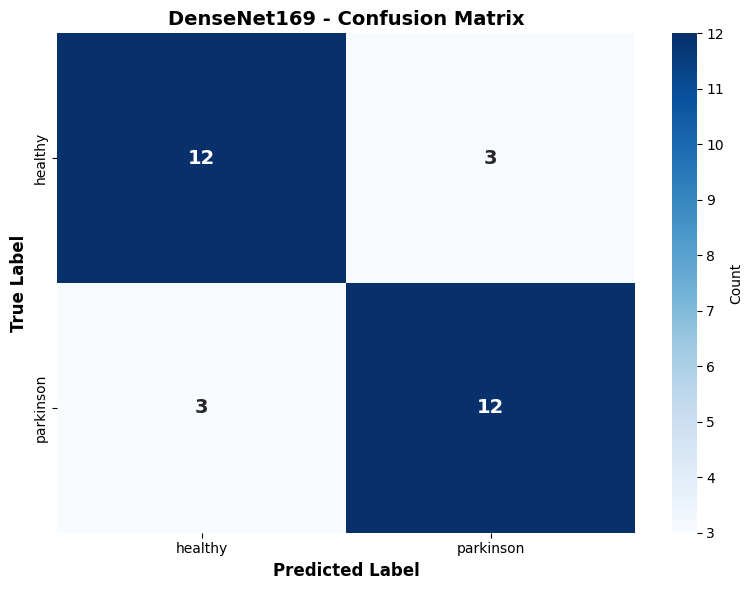

Confusion Matrix saved: DenseNet169_confusion_matrix.png

DenseNet169 TRAINING COMPLETE!
  Test Accuracy: 80.00%
  Test AUC: 0.7467
  Threshold: 0.46
  Test Loss: 0.6145


In [13]:
print('\n' + '=' * 60)
print('TRAINING MODEL 4/4: DenseNet169')
print('=' * 60)

results['DenseNet169'] = train_model('DenseNet169')

print(f"\n{'=' * 60}")
print('DenseNet169 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['DenseNet169']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['DenseNet169']['test_auc']:.4f}")
print(f"  Threshold: {results['DenseNet169']['threshold']:.2f}")
print(f"  Test Loss: {results['DenseNet169']['test_loss']:.4f}")
print(f"{'=' * 60}")

---
## STEP 5: VISUALIZE RESULTS

In [17]:
# Summary table
print('\n' + '=' * 70)
print('TRAINING RESULTS SUMMARY')
print('=' * 70)
print(f"{'Model':<15} {'Test Accuracy':<15} {'Test AUC':<12} {'Threshold':<10} {'Best Epoch':<10}")
print('-' * 80)

for model_name, data in results.items():
    best_epoch = np.argmax(data['history'].history['val_auc']) + 1
    print(f"{model_name:<15} {data['test_acc'] * 100:>6.2f}%         {data['test_auc']:<12.4f} {data['threshold']:<10.2f} {best_epoch:<10}")

best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print('\n' + '=' * 70)
print(f"BEST MODEL: {best_model_name} ({results[best_model_name]['test_acc'] * 100:.2f}%)")
print('=' * 70)


TRAINING RESULTS SUMMARY
Model           Test Accuracy   Test AUC     Threshold  Best Epoch
--------------------------------------------------------------------------------
VGG19            83.33%         0.7778       0.36       8         
DenseNet169      80.00%         0.7467       0.46       9         
InceptionV3      73.33%         0.8978       0.48       10        
ResNet50V2       70.00%         0.7778       0.54       3         

BEST MODEL: VGG19 (83.33%)


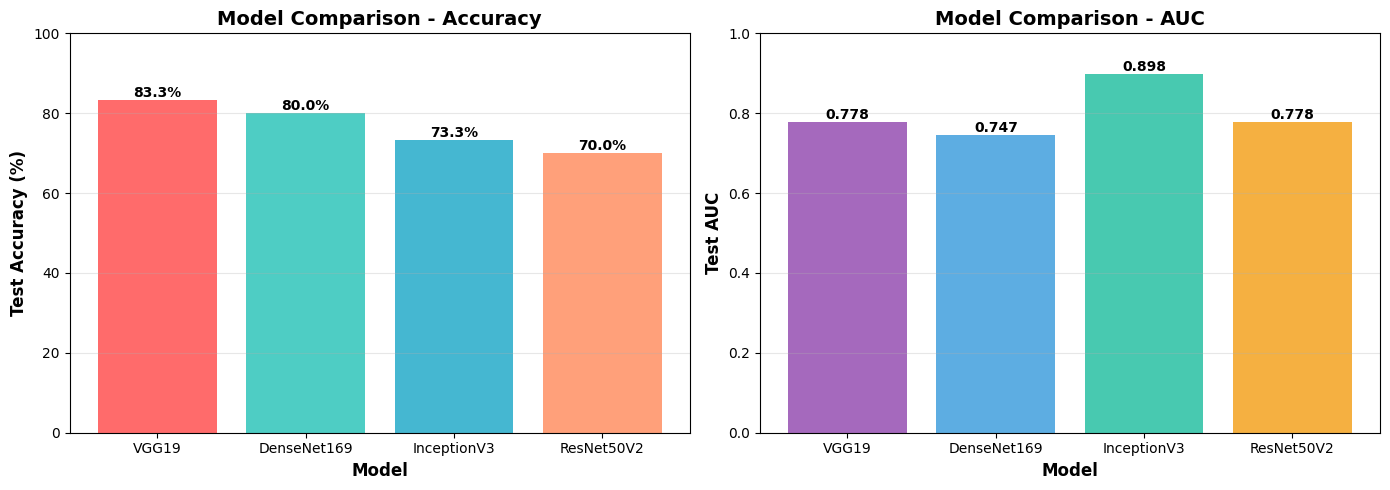

Comparison plot saved: model_comparison.png


In [18]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())
accuracies = [results[m]['test_acc'] * 100 for m in model_names]
aucs = [results[m]['test_auc'] for m in model_names]

bars1 = axes[0].bar(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_title('Model Comparison - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
axes[0].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2., height, f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(model_names, aucs, color=['#A569BD', '#5DADE2', '#48C9B0', '#F5B041'])
axes[1].set_ylabel('Test AUC', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison - AUC', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)

for bar, auc in zip(bars2, aucs):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2., height, f'{auc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Comparison plot saved: model_comparison.png')

---
## STEP 6: SAVE MODELS

In [ ]:
print('Saving models to Google Drive...\n')

threshold_rows = []

for model_name, data in results.items():
    model_file = os.path.join(SAVE_PATH, f'{model_name}_spiral_optimized.keras')
    data['model'].save(model_file)
    threshold_rows.append({'model': model_name, 'threshold': data['threshold'], 'test_accuracy': data['test_acc'], 'test_auc': data['test_auc']})
    print(f'Saved: {model_file}')

threshold_df = pd.DataFrame(threshold_rows)
threshold_file = os.path.join(SAVE_PATH, 'model_thresholds.csv')
threshold_df.to_csv(threshold_file, index=False)
print(f'Saved: {threshold_file}')

print('\nAll models saved to Google Drive!')